# Autoencoder

In [1]:
# Encoding
# resude the size of the inputs into a smaller 
# reduce format is known as latent space representation

# application
# image coloring
# water mark removal

# encode-low to higher
# code-save
# decode


# bottleneck - layer btw encoder and decoder


# types of autoencoders
# 1) vanilla autoencoders-only hidden layer, fully connected ntwrk layer
# 2) deep autoencoders-more hidden layers,
# 3)convolutional autoencoders-conv2d,maxpooling
# 4) regularized autoencoders-
#    1) sparse autoencoders-few layers passed next layer,relevent data pass
#    2) denoising autoencoders-noise reduce ,training(noise reduce)and testing(clean image) data are different,feature extraction 

#  Vanilla Autoencoders

In [2]:
from keras.models import Sequential
from keras.layers import Input,Dense
from keras.models import Model
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

In [3]:
(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255

In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
x_train=x_train.reshape((x_train.shape[0],x_train.shape[1]*x_train.shape[2]))
x_test=x_test.reshape((x_test.shape[0],x_test.shape[1]*x_test.shape[2]))

In [6]:
x_train.shape

(60000, 784)

In [7]:
INPUT_SIZE=784
ENCODING_SIZE=64
input_img=Input(shape=(INPUT_SIZE,))

In [8]:
encoded=Dense(ENCODING_SIZE,activation='relu')(input_img)
decoded=Dense(INPUT_SIZE,activation='relu')(encoded)
autoencoder=Model(input_img,decoded)

In [9]:
autoencoder.compile(optimizer='adam',loss='mean_squared_error')
autoencoder.fit(x_train,x_train,epochs=50,batch_size=256,shuffle=True,validation_split=0.2)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0359 - val_loss: 0.0173
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0142 - val_loss: 0.0122
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0113 - val_loss: 0.0106
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0102 - val_loss: 0.0098
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0096 - val_loss: 0.0094
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0092 - val_loss: 0.0091
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0090 - val_loss: 0.0089
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0089 - val_loss: 0.0088
Epoch 9/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0087 - val_loss: 0.0086
Epoch 10/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0086 - val_loss: 0.0086
Epoch 11/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0085 - val_loss: 0.0084
Epoch 12/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 

In [10]:
decoded_img=autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


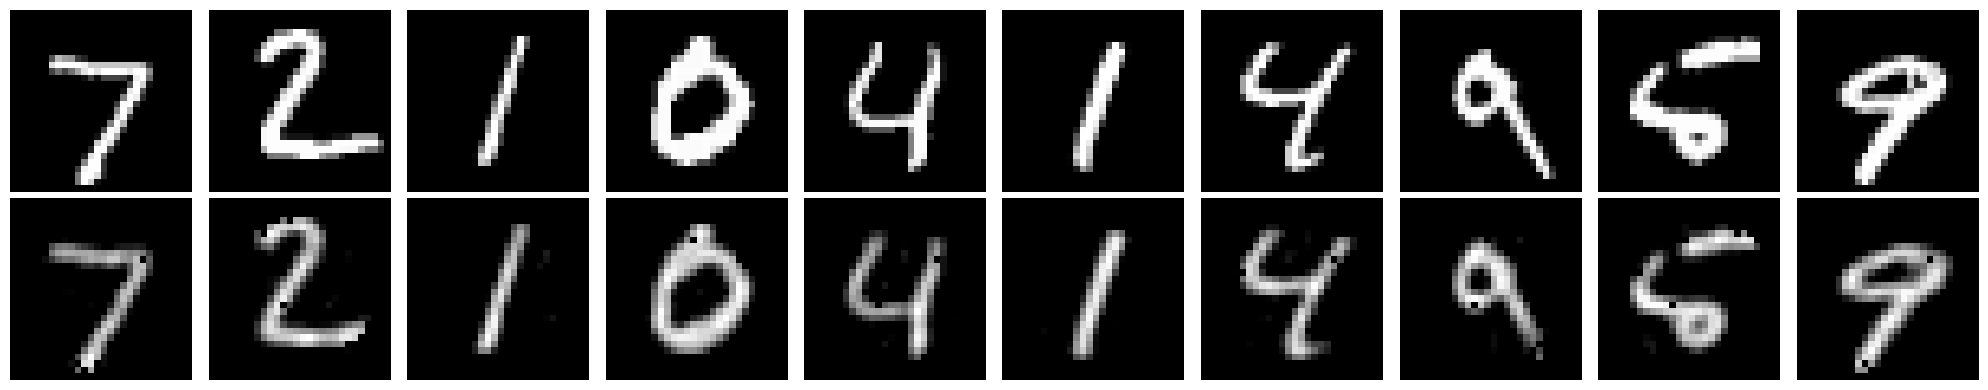

In [11]:
plt.figure(figsize=(20,4))
for i in range(10):
    #original
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28))
    plt.gray()
    plt.axis('off')
    #reconstruction
    plt.subplot(2,10,i+11)
    plt.imshow(decoded_img[i].reshape(28,28))
    plt.gray()
    plt.axis('off')
plt.tight_layout()
plt.show()

# deep autoencoders

In [12]:
input_img=Input(shape=(INPUT_SIZE,))
encoded=Dense(512,activation='relu')(input_img)
encoded=Dense(256,activation='relu')(encoded)
encoded=Dense(128,activation='relu')(encoded)

encoded=Dense(128,activation='relu')(encoded)

decoded=Dense(128,activation='relu')(encoded)
decoded=Dense(256,activation='relu')(decoded)
decoded=Dense(512,activation='relu')(decoded)
decoded=Dense(INPUT_SIZE,activation='relu')(decoded)
autoencoder=Model(input_img,decoded)

In [13]:
autoencoder.compile(optimizer='adam',loss='mean_squared_error')
autoencoder.fit(x_train,x_train,epochs=50,batch_size=256,shuffle=True,validation_split=0.2)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - loss: 0.0356 - val_loss: 0.0197
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - loss: 0.0164 - val_loss: 0.0169
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - loss: 0.0132 - val_loss: 0.0122
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 0.0117 - val_loss: 0.0110
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - loss: 0.0107 - val_loss: 0.0106
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 0.0100 - val_loss: 0.0101
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - loss: 0.0095 - val_loss: 0.0093
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 0.0091 - val_loss: 0.0092
Epoch 9/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - loss: 0.0088 - val_loss: 0.0089
Epoch 10/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 0.0085 - val_loss: 0.0085
Epoch 11/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 0.0082 - val_loss: 0.0086
Epoch 12/50
188/188 ━━━━━━━━━━

In [14]:
decoded_img=autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


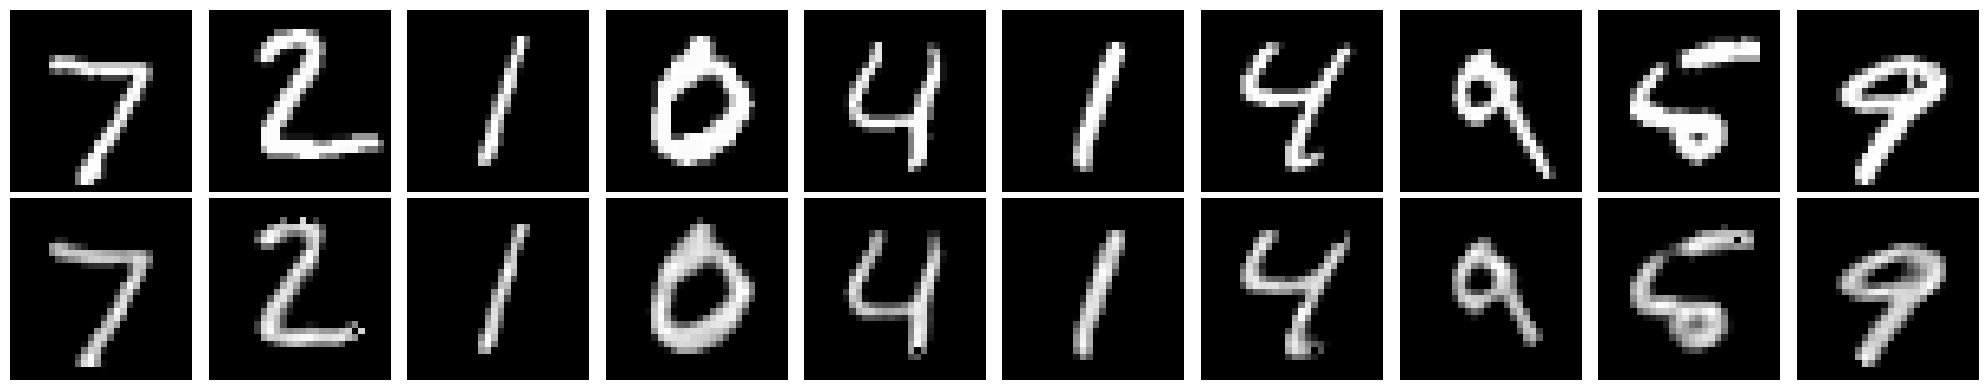

In [15]:
plt.figure(figsize=(20,4))
for i in range(10):
    #original
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28))
    plt.gray()
    plt.axis('off')
    #reconstruction
    plt.subplot(2,10,i+11)
    plt.imshow(decoded_img[i].reshape(28,28))
    plt.gray()
    plt.axis('off')
plt.tight_layout()
plt.show()

In [16]:
# Convolutionaal Autoencoders

In [17]:
from tensorflow.keras.layers import Conv2D,MaxPooling2D,UpSampling2D


In [18]:
(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255
x_train.shape

(60000, 28, 28)

In [19]:
x_train=x_train.reshape((x_train.shape[0],28,28,1))
x_test=x_test.reshape((x_test.shape[0],28,28,1))

In [20]:
autoencoder=Sequential()
autoencoder.add(Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(28,28,1)))
autoencoder.add(MaxPooling2D((2,2),padding='same'))
autoencoder.add(Conv2D(8,(3,3),activation='relu',padding='same'))
autoencoder.add(MaxPooling2D((2,2),padding='same'))
autoencoder.add(Conv2D(8,(3,3),activation='relu',padding='same'))
autoencoder.add(UpSampling2D((2,2)))
autoencoder.add(Conv2D(32,(3,3),activation='relu',padding='same'))
autoencoder.add(UpSampling2D((2,2)))
autoencoder.add(Conv2D(1,(3,3),activation='sigmoid',padding='same'))
#to convert to shape (28,28,1)

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder.fit(x_train,x_train,epochs=10,batch_size=256,shuffle=True,validation_split=0.2)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - loss: 0.2150 - val_loss: 0.1032
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - loss: 0.0933 - val_loss: 0.0887
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - loss: 0.0852 - val_loss: 0.0839
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - loss: 0.0817 - val_loss: 0.0813
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - loss: 0.0796 - val_loss: 0.0794
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - loss: 0.0780 - val_loss: 0.0781
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - loss: 0.0769 - val_loss: 0.0773
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - loss: 0.0760 - val_loss: 0.0763
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - loss: 0.0753 - val_loss: 0.0756
Epoch 10/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - loss: 0.0747 - val_loss: 0.0750


In [22]:
decoded_img=autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


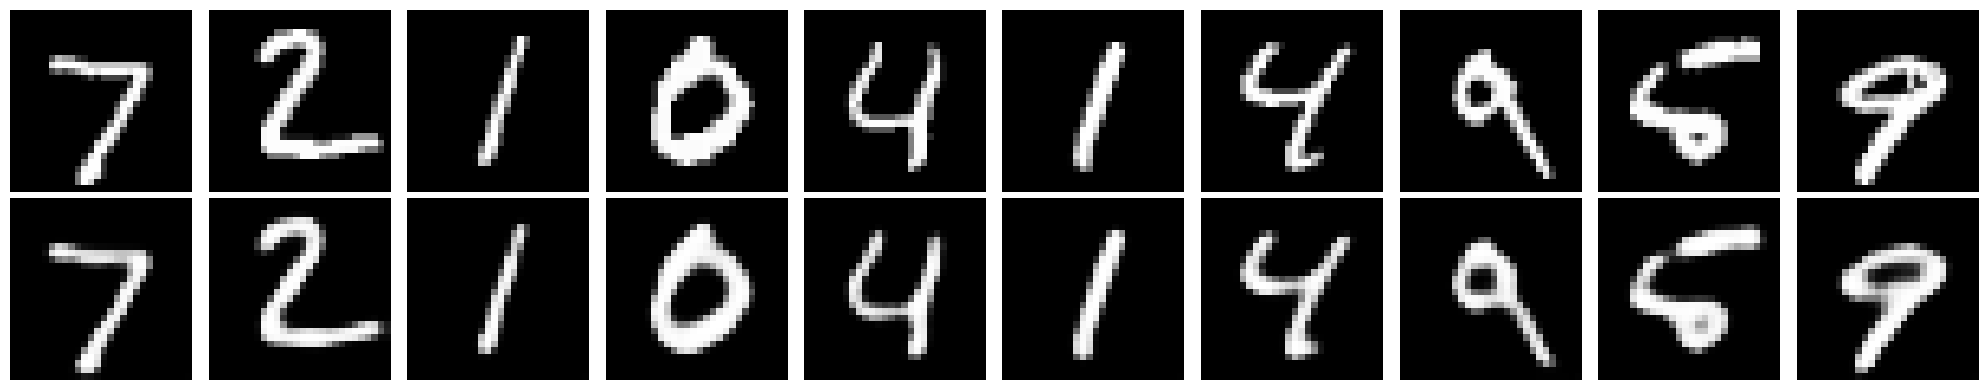

In [23]:
plt.figure(figsize=(20,4))
for i in range(10):
    #original
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28))
    plt.gray()
    plt.axis('off')
    #reconstruction
    plt.subplot(2,10,i+11)
    plt.imshow(decoded_img[i].reshape(28,28))
    plt.gray()
    plt.axis('off')
plt.tight_layout()
plt.show()

In [24]:
print(decoded_img.min(),decoded_img.max())

5.403904e-13 0.9990253


In [ ]:
# Sparse autoencoders

In [25]:
from keras import regularizers

In [28]:
(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255
x_train=x_train.reshape(len(x_train),np.prod(x_train.shape[1:]))
#np.prod to multiply (60000,28,28)
x_test=x_test.reshape(len(x_test),np.prod(x_test.shape[1:]))
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [32]:
input_img=Input(shape=(784,))
encoding_dim=32
#add dense layer with a L1 activity regularizer
encoded=Dense(encoding_dim,activation='relu',activity_regularizer=regularizers.l1(10e-5))(input_img)
decoded=Dense(784,activation='sigmoid')(encoded)
autoencoder=Model(input_img,decoded)

In [33]:
autoencoder.compile(optimizer='adam',loss='mean_squared_error')
autoencoder.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 784)                 │          25,872 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
autoencoder.fit(x_train,x_train,epochs=10,batch_size=256,shuffle=True,validation_split=0.2)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0846 - val_loss: 0.0518
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0442 - val_loss: 0.0385
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0354 - val_loss: 0.0323
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0305 - val_loss: 0.0283
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0271 - val_loss: 0.0256
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0248 - val_loss: 0.0237
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0230 - val_loss: 0.0222
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0216 - val_loss: 0.0209
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0204 - val_loss: 0.0200
Epoch 10/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0195 - val_loss: 0.0192


In [35]:
decoded_img=autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


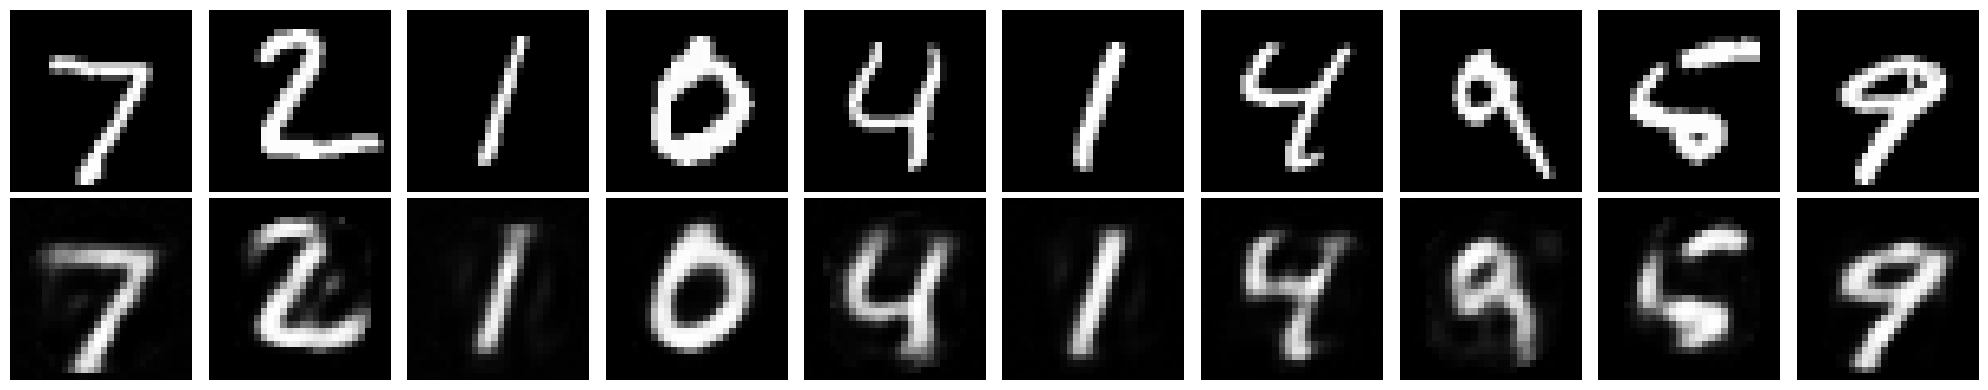

In [36]:
plt.figure(figsize=(20,4))
for i in range(10):
    #original
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28))
    plt.gray()
    plt.axis('off')
    #reconstruction
    plt.subplot(2,10,i+11)
    plt.imshow(decoded_img[i].reshape(28,28))
    plt.gray()
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Denoising autoencoders

In [39]:
(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255
x_train=np.reshape(x_train,(len(x_train),28,28,1))
x_test=np.reshape(x_test,(len(x_test),28,28,1))

In [40]:
noise_factor=0.5
#(loc=0.0)=this parameter sets the mean of the normal distribution to 0.,
#(scale=1.0)=this parameter sets the std deviation of the normal distribution to 1.
x_train_noisy=x_train+noise_factor*np.random.normal(loc=0.0,scale=1.0,size=x_train.shape)
x_test_noisy=x_test+noise_factor*np.random.normal(loc=0.0,scale=1.0,size=x_test.shape)
#by applying this clipping operation,the pixel values in the noisy images
#are constructed to be btw 0 and 1
x_train_noisy=np.clip(x_train_noisy,0.,1.) #np.clip(array,min_value,max_value)
x_test_noisy=np.clip(x_test_noisy,0.,1.)

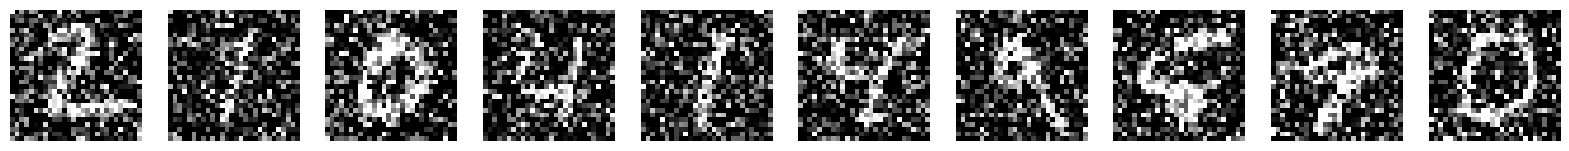

In [41]:
# visualizing noisy input
n=10
plt.figure(figsize=(20,2))
for i in range(1,n+1):
    ax=plt.subplot(1,n,i)
    plt.imshow(x_test_noisy[i].reshape(28,28))
    plt.gray()
    plt.axis('off')
plt.show()

In [45]:
input_img=Input(shape=(28,28,1))
x=Conv2D(32,(3,3),activation='relu',padding='same')(input_img)
x=MaxPooling2D((2,2),padding='same')(x)
x=Conv2D(32,(3,3),activation='relu',padding='same')(x)
encoded=MaxPooling2D((2,2),padding='same')(x)


x=Conv2D(32,(3,3),activation='relu',padding='same')(encoded)
x=UpSampling2D((2,2))(x)
x=Conv2D(32,(3,3),activation='relu',padding='same')(x)
x=UpSampling2D((2,2))(x)
decoded=Conv2D(1,(3,3),activation='sigmoid',padding='same')(x)

autoencoder=Model(input_img,decoded)

In [46]:
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder.fit(x_train,x_train,epochs=10,batch_size=256,shuffle=True,validation_split=0.2)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 28s 128ms/step - loss: 0.1558 - val_loss: 0.0861
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 40s 123ms/step - loss: 0.0803 - val_loss: 0.0777
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 122ms/step - loss: 0.0755 - val_loss: 0.0746
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 123ms/step - loss: 0.0732 - val_loss: 0.0739
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - loss: 0.0719 - val_loss: 0.0722
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 23s 123ms/step - loss: 0.0710 - val_loss: 0.0711
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 23s 122ms/step - loss: 0.0703 - val_loss: 0.0709
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 123ms/step - loss: 0.0698 - val_loss: 0.0700
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 123ms/step - loss: 0.0693 - val_loss: 0.0696
Epoch 10/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 123ms/step - loss: 0.0689 - val_loss: 0.0692


In [47]:
decoded_img=autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


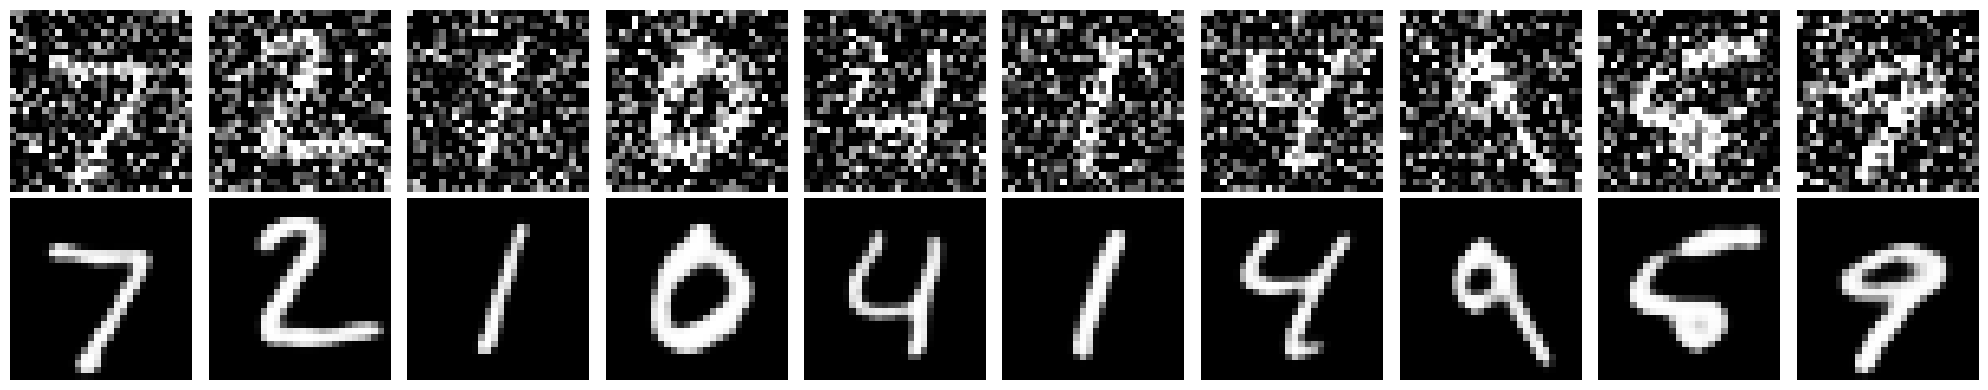

In [48]:
plt.figure(figsize=(20,4))
for i in range(10):
    #original
    plt.subplot(2,10,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28))
    plt.gray()
    plt.axis('off')
    #reconstruction
    plt.subplot(2,10,i+11)
    plt.imshow(decoded_img[i].reshape(28,28))
    plt.gray()
    plt.axis('off')
plt.tight_layout()
plt.show()